In [17]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
sys.path.append(str(Path.cwd().parent))
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
# from utils.CBEM import CBEM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100 #

PyTorch: 2.10.0+cu128
CUDA available: False


## Load Data to evaluate model

In [18]:
project_root = Path.cwd().parent
models_dir = "saved_models"
data_dir = project_root / "Data"

In [19]:
file_path = data_dir / "PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz"
data_test   = np.load(file_path, allow_pickle=True)
stim_rs        = data_test["stim"]
spktimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)

In [20]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_rs.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)


spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]


psth_hz = spk_test.mean(axis=0) / dt   # [T] in Hz
psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=int(0.02 / dt))  # 20 ms smoothing



In [21]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [22]:
## LOAD trained model
ckpt_full = torch.load(f"{models_dir}/fuck_yeah.pt", map_location=device)

trained = CBEM_trials(binsize_s=ckpt_full["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_full["model_state_dict"]["B_cond"].shape[0]
trained._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

trained.load_state_dict(ckpt_full["model_state_dict"])
trained.eval()

steps_hist = ckpt_full.get("steps_hist", None)
loss_hist  = ckpt_full.get("loss_hist", None)

##Load Linear model
ckpt_linear = torch.load(f"{models_dir}/lin_model.pt", map_location=device)

cbem_lin = CBEM_linear(binsize_s=ckpt_linear["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_linear["model_state_dict"]["B_cond"].shape[0]
cbem_lin._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

cbem_lin.load_state_dict(ckpt_linear["model_state_dict"])
cbem_lin.eval()


CBEM_linear()

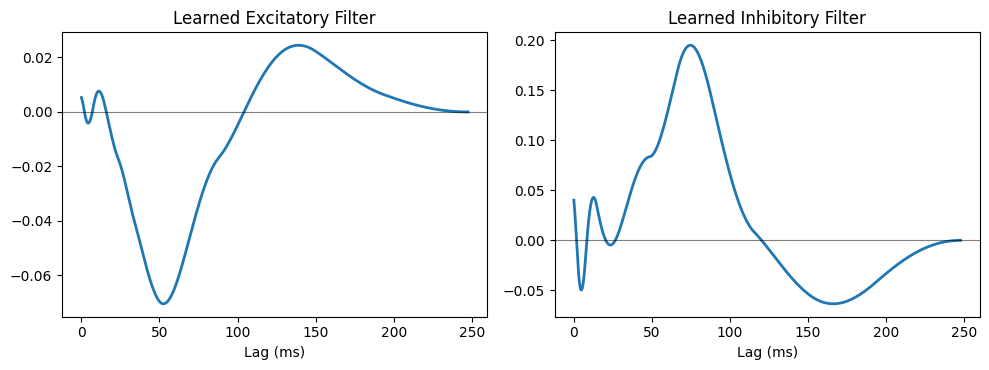

In [23]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

B_orth_t = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = B_orth_t @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## Evaluate trained model

In [24]:
##Design Matrix test stim
stim_test_t = torch.as_tensor(stimulus_test, dtype=torch.float32, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_test_tr = [
    convolveStimulusWithBasis_torch(stim_test_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_test.shape[0])
]
X_test = torch.stack(X_test_tr, dim=0)  # [B,T,D]
print('X_full:', X_test.shape)


def simulate_model(trained, X_test):
    ## FULL MODEL
    with torch.no_grad():
        rate_test, aux = trained(X_test)  # [B,T]
        
    B = X_test.shape[0]
    T0 = 500
    Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)  # [B,T0]
    sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()
    # sps: [B,T] in {0,1}
    B, T = sps_t.shape
    

    return rate_test, aux, sps_t

rate_test, aux, sps_t = simulate_model(trained, X_test)

# Build spike times (ms) per trial for eventplot
spkTimes_ms_by_trial = [
        np.where(sps_t[b, :] > 0)[0] * dt * 1e3
        for b in range(rate_test.shape[0])]
## LIN MODEL STATS
with torch.no_grad():
    psth_lin, aux_lin = cbem_lin(X_test)  # [B,T]
    
    


X_full: torch.Size([6, 100000, 11])


In [25]:
trained.g_l, trained.E_l

(tensor(200.), tensor(-60.))

In [26]:
rate_hat = rate_test.detach().cpu()
rate_lin = psth_lin.detach().cpu()

rate_hat = gaussian_filter1d(rate_hat[0], sigma=max(1, int(0.02 / dt)))  # 20 ms
rate_lin = gaussian_filter1d(rate_lin[0], sigma=max(1, int(0.02 / dt)))  # 20 ms

In [27]:
gs = aux['gs']
Vm = aux['V']
gs.shape, Vm.shape

(torch.Size([6, 100000, 2]), torch.Size([6, 100000]))

In [28]:
dt_s = 1e-4
trial = 1
L = 100000

Vm_np = Vm.detach().cpu().numpy() if hasattr(Vm, "detach") else Vm
t_ms = np.arange(L) * dt_s * 1e3

spk_idx = np.where(sps_t[trial, :L] > 0)[0]
spk_ms  = spk_idx * dt_s * 1e3

Vm0 = Vm_np[trial, :L]
Vm_at_spk = Vm0[spk_idx]



# make each spike a short tick starting at Vm(t_spike)


## Conductance -> current -> ATP

$g(t) \to I_{ion}(t) \to Q_{ion} \to N_{ions} \to ATP$
- Synpatic currents

    $I_{exc}(t) = g_{exc}(t) * (E_{exc} - V_m(t))$ 

    and 

    $I_{inh}(t) = g_{inh}(t) * (E_{inh} - V_m(t))$

    Using $E_{exc} = 0 mV$ and $E_{inh} = -80 mv$
- Leak current

    $I_{leak}(t) = g_{leak} * (E_{leak} - V_m(t))$
- Spiking currents


In [34]:
import torch

E_CHARGE = 1.602176634e-19  # C


def sodium_conductance_from_total(g_syn, E_syn, E_Na=60.0, E_K=-80.0):
    """
    g_syn: total conductance [B,T] or compatible, in nS
    E_syn, E_Na, E_K: mV
    returns g_Na in nS
    """
    frac_na = (E_syn - E_K) / (E_Na - E_K)
    return g_syn * frac_na


def sodium_current_from_total(g_syn, Vm, E_syn, E_Na=60.0, E_K=-80.0):
    """
    g_syn: nS
    Vm: mV
    returns I_Na in pA
    """
    g_Na = sodium_conductance_from_total(g_syn, E_syn=E_syn, E_Na=E_Na, E_K=E_K)
    I_Na = g_Na * (E_Na - Vm)   # pA
    return I_Na


def inward_charge_from_current(I, dt):
    """
    I in pA, dt in s
    Assumes inward current is positive under your sign convention.
    Returns charge in Coulombs.
    """
    # I_in = torch.clamp(I, min=0.0)
    Q = (I * dt * 1e-12).sum(dim=1)
    return Q


def atp_from_na_charge(Q_Na):
    """
    Q_Na in Coulombs
    returns ATP molecule count
    """
    N_Na = Q_Na / E_CHARGE
    ATP = N_Na / 3.0
    return ATP

In [45]:
I_Na_exc = sodium_current_from_total(gs[..., 0], Vm, E_syn=0.0, E_Na=60.0, E_K=-80.0)
Q_Na_exc = inward_charge_from_current(I_Na_exc, dt)
ATP_exc = atp_from_na_charge(Q_Na_exc)

I_Na_leak = sodium_current_from_total(trained.g_l, Vm, E_syn=-60.0, E_Na=60.0, E_K=-80.0)
Q_Na_leak = inward_charge_from_current(I_Na_leak, dt)
ATP_leak = atp_from_na_charge(Q_Na_leak)

ATP_exc, ATP_leak

(tensor([1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10, 1.3390e+10]),
 tensor([7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10, 7.0568e+10]))

In [46]:
g_l_span = torch.linspace(100, 300, 10, device=trained.g_l.device, dtype=trained.g_l.dtype)

results = []
g_l_orig = trained.g_l.clone()

for g_l_val in g_l_span:
    with torch.no_grad():
        trained.g_l.fill_(g_l_val)

        rate_test, aux = trained(X_test)

        B = X_test.shape[0]
        T0 = 500
        Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)
        sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0)

        gs = aux["gs"]       # [B,T,2]
        Vm = aux["V"]        # [B,T]

        # --- Excitatory Na current / ATP ---
        I_Na_exc = sodium_current_from_total(
            gs[..., 0], Vm,
            E_syn=0.0,      # excitatory reversal
            E_Na=60.0,
            E_K=-80.0
        )
        Q_Na_exc = inward_charge_from_current(I_Na_exc, dt)
        ATP_exc = atp_from_na_charge(Q_Na_exc)

        # --- Leak Na current / ATP ---
        I_Na_leak = sodium_current_from_total(
            g_l_val, Vm,
            E_syn=-60.0,    # your leak reversal
            E_Na=60.0,
            E_K=-80.0
        )
        Q_Na_leak = inward_charge_from_current(I_Na_leak, dt)
        ATP_leak = atp_from_na_charge(Q_Na_leak)

        # --- Spikes ---
        spike_counts = sps_t.sum(dim=1)
        rate_hz_trial = spike_counts / (sps_t.shape[1] * dt)

        # Optional spike-cost term
        ATP_spike = torch.zeros_like(ATP_exc)
        # Example if later desired:
        # c_spike_atp = 1e8
        # ATP_spike = c_spike_atp * spike_counts

        ATP_total = ATP_exc + ATP_leak + ATP_spike

        ATP_total_per_spike = torch.full_like(ATP_total, float("nan"))
        mask = spike_counts > 0
        ATP_total_per_spike[mask] = ATP_total[mask] / spike_counts[mask]

        results.append({
            "g_l": float(g_l_val.item()),
            "mean_ATP_exc": ATP_exc.mean().item(),
            "mean_ATP_leak": ATP_leak.mean().item(),
            "mean_ATP_total": ATP_total.mean().item(),
            "mean_ATP_per_spike": torch.nanmean(ATP_total_per_spike).item(),
            "mean_spike_count": spike_counts.float().mean().item(),
            "mean_rate_hz": rate_hz_trial.mean().item(),
            "mean_Vm": Vm.mean().item(),
            "std_Vm": Vm.std().item(),
            "mean_g_exc": gs[..., 0].mean().item(),
            "mean_g_inh": gs[..., 1].mean().item(),
            "mean_Q_Na_exc": Q_Na_exc.mean().item(),
            "mean_Q_Na_leak": Q_Na_leak.mean().item(),
        })

with torch.no_grad():
    trained.g_l.copy_(g_l_orig)

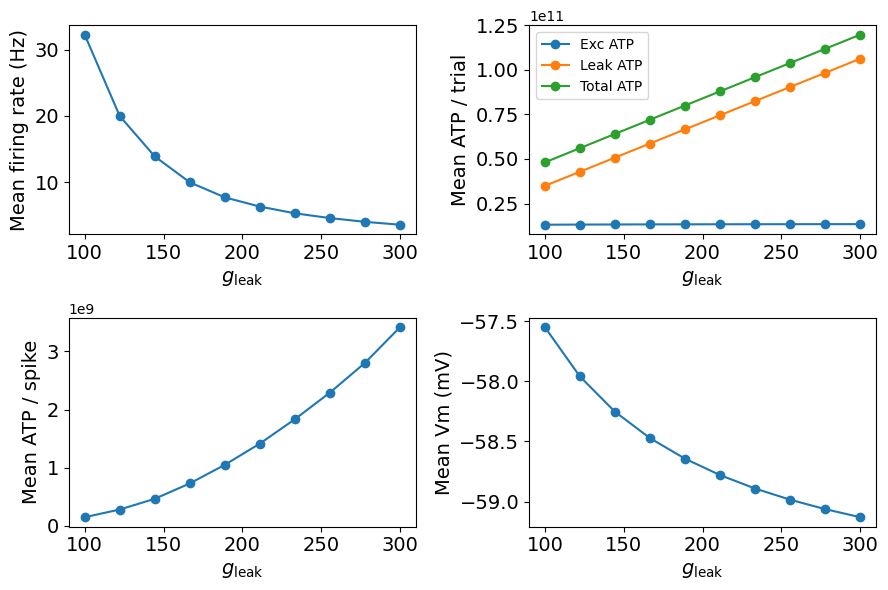

In [60]:
import numpy as np
import matplotlib.pyplot as plt

g_l_vals = np.array([r["g_l"] for r in results])
mean_rate = np.array([r["mean_rate_hz"] for r in results])
mean_ATP_exc = np.array([r["mean_ATP_exc"] for r in results])
mean_ATP_leak = np.array([r["mean_ATP_leak"] for r in results])
mean_ATP_total = np.array([r["mean_ATP_total"] for r in results])
mean_ATP_per_spike = np.array([r["mean_ATP_per_spike"] for r in results])
mean_Vm = np.array([r["mean_Vm"] for r in results])

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

axes[0, 0].plot(g_l_vals, mean_rate, '-o')
axes[0, 0].set_xlabel("g_l")
axes[0, 0].set_ylabel("Mean firing rate (Hz)",  fontsize=14)

axes[0, 1].plot(g_l_vals, mean_ATP_exc, '-o', label="Exc ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_leak, '-o', label="Leak ATP")
axes[0, 1].plot(g_l_vals, mean_ATP_total, '-o', label="Total ATP")
axes[0, 1].set_xlabel("g_l")
axes[0, 1].set_ylabel("Mean ATP / trial",  fontsize=14)
axes[0, 1].legend()

axes[1, 0].plot(g_l_vals, mean_ATP_per_spike, '-o')
axes[1, 0].set_xlabel("g_l")
axes[1, 0].set_ylabel("Mean ATP / spike",  fontsize=14)

axes[1, 1].plot(g_l_vals, mean_Vm, '-o')
axes[1, 1].set_xlabel("g_l")
axes[1, 1].set_ylabel("Mean Vm (mV)", fontsize=14)

for ax in axes.flat:
    ax.set_xlabel(r"$g_{\mathrm{leak}}$", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    
fig.tight_layout()
fig.savefig(fname='g_leak_span', bbox_inches='tight', dpi=300)
plt.show()

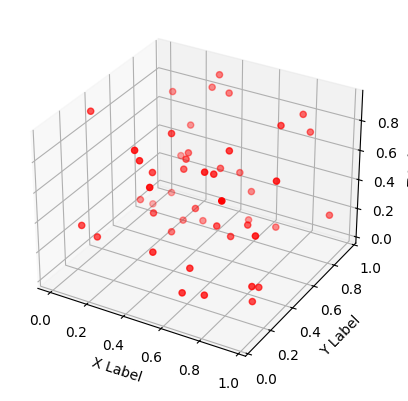

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Import the mplot3d toolkit
from mpl_toolkits.mplot3d import Axes3D

# Create data
# For a real application, you would use your own data
x = np.random.rand(50)
y = np.random.rand(50)
z = np.random.rand(50)

# Create a figure and a 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # or use ax = plt.axes(projection='3d')

# Plot the data
ax.scatter(x, y, z, c='r', marker='o') # 'c' for color, 'marker' for point style

# Set labels for axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Display the plot
plt.show()
